# RECOVER Cohort — BMI × Long COVID Subphenotype Analysis
**Targets:** NPJ Digital Medicine / Nature Medicine / Nature Communications  
**Install once:** `pip install pandas numpy scipy statsmodels matplotlib seaborn pingouin tableone`

In [1]:
import warnings, os
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.stats.mediation import Mediation
import pingouin as pg
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tableone import TableOne

warnings.filterwarnings('ignore')
OUTDIR = Path('./results')
OUTDIR.mkdir(exist_ok=True)

# ── Nature/NPJ style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial','Helvetica','DejaVu Sans'],
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
})
PALETTE   = {'Protected': '#4878CF', 'Responder': '#6ACC65', 'Refractory': '#D65F5F'}
SUBGROUPS = ['Protected', 'Responder', 'Refractory']
BMI_BINS   = [0, 18.5, 25, 30, np.inf]
BMI_LABELS = ['Underweight\n(<18.5)', 'Normal\n(18.5–25)',
               'Overweight\n(25–30)', 'Obese\n(≥30)']
print('Imports OK')

Imports OK


## 1. File Paths — edit these three lines

In [3]:
BMI_PATH          = 'bmi.csv'           # PARTICIPANT_ID, DATA_ENTRY_DATE, DATA_FIELD_NAME, ANSWER_NUMERIC_VAL
PASC_PATH         = 'pasc_df_2026.csv'          # id, index, date, name  (name = PASC score)
SUBPHENOTYPE_PATH = 'subphenotype.csv'  # arr1, arr2, arr3  (each column = list of participant IDs)
subphenotype  = np.load('three_cohorts2026.npz',allow_pickle=True)
arr1 = subphenotype['arr1']
arr2 = subphenotype['arr2']
arr3 = subphenotype['arr3']


## 2. Load & Parse Data

In [25]:
# ── BMI ───────────────────────────────────────────────────────────────────
bmi_raw = pd.read_csv(BMI_PATH, parse_dates=['DATA_ENTRY_DATE'])
bmi_raw.columns = bmi_raw.columns.str.strip().str.upper()
bmi_raw = bmi_raw[bmi_raw['DATA_FIELD_NAME'].str.upper().str.strip() == 'BMI'].copy()
bmi_raw = bmi_raw.rename(columns={
    'PARTICIPANT_ID':    'pid',
    'DATA_ENTRY_DATE':   'date',
    'ANSWER_NUMERIC_VAL': 'bmi',
})[['pid','date','bmi']]
bmi_raw = bmi_raw[(bmi_raw['bmi'] >= 10) & (bmi_raw['bmi'] <= 80)].dropna(subset=['bmi'])

print(f'BMI records  : {len(bmi_raw):,}  |  participants: {bmi_raw["pid"].nunique():,}')
bmi_raw.head(3)

In [26]:
# ── PASC ──────────────────────────────────────────────────────────────────
# Columns: id, index, date, name
pasc_raw = pd.read_csv(PASC_PATH, parse_dates=['date'])
pasc_raw = pasc_raw.rename(columns={
    'id':   'pid',
    'name': 'pasc',
})[['pid','date','pasc']]
pasc_raw['pasc'] = pd.to_numeric(pasc_raw['pasc'], errors='coerce')
pasc_raw = pasc_raw.dropna(subset=['pasc'])

print(f'PASC records : {len(pasc_raw):,}  |  participants: {pasc_raw["pid"].nunique():,}')
pasc_raw.head(3)

In [27]:
# ── Subphenotype ──────────────────────────────────────────────────────────
# arr1 = Protected, arr2 = Responder, arr3 = Refractory
# Each column contains participant IDs (rows may be ragged; NaNs are dropped)
# sp_raw = pd.read_csv(SUBPHENOTYPE_PATH)

subpheno_rows = []
for col, label in zip([arr1,arr2,arr3], SUBGROUPS):
    ids = col #sp_raw[col].dropna().astype(str).str.strip().tolist()
    subpheno_rows.extend([(pid, label) for pid in ids if pid != ''])

subpheno = pd.DataFrame(subpheno_rows, columns=['pid','group'])
subpheno['pid'] = subpheno['pid'].astype(str)
bmi_raw['pid']  = bmi_raw['pid'].astype(str)
pasc_raw['pid'] = pasc_raw['pid'].astype(str)

print('Subphenotype counts:')
print(subpheno['group'].value_counts().to_string())
subpheno.head(3)

## 3. Build Analysis DataFrame

In [9]:
# Pre-infection BMI = earliest record per participant
bmi_pre = (bmi_raw.sort_values('date')
           .groupby('pid', as_index=False).first()
           .rename(columns={'bmi': 'bmi_pre', 'date': 'bmi_date'})
           [['pid','bmi_pre','bmi_date']])

peak_pasc    = pasc_raw.groupby('pid')['pasc'].max().reset_index(name='peak_pasc')
initial_pasc = (pasc_raw.sort_values('date')
                .groupby('pid', as_index=False).first()
                .rename(columns={'pasc':'initial_pasc'})[['pid','initial_pasc']])

df = (subpheno
      .merge(bmi_pre,      on='pid', how='left')
      .merge(peak_pasc,    on='pid', how='left')
      .merge(initial_pasc, on='pid', how='left'))

df['bmi_cat']    = pd.cut(df['bmi_pre'], bins=BMI_BINS, labels=BMI_LABELS, right=False)
df['long_covid'] = (df['peak_pasc'] >= 12).astype(int)

df.to_csv(OUTDIR / 'analysis_df.csv', index=False)
print(f'Analysis df  : {len(df):,} rows  |  BMI available: {df["bmi_pre"].notna().sum():,}')
df.describe()

Analysis df  : 13,511 rows  |  BMI available: 13,137


,bmi_pre,bmi_date,peak_pasc,initial_pasc,long_covid
count,13137.000000,13137,13511.000000,13511.000000,13511.000000
mean,29.518794,2022-04-03 19:39:20.264900608,8.256162,4.502331,0.293613
min,10.300000,2021-01-01 00:00:00,0.000000,0.000000,0.000000
25%,24.000000,2022-01-01 00:00:00,1.000000,0.000000,0.000000
50%,28.000000,2022-01-07 00:00:00,7.000000,1.000000,0.000000
75%,33.400000,2022-02-28 00:00:00,13.000000,7.000000,1.000000
max,79.800000,2025-05-12 00:00:00,30.000000,30.000000,1.000000
std,7.645427,NaN,7.594256,6.457466,0.455433


## 4. Table 1 — Summary Statistics

In [10]:
cols     = ['bmi_pre','bmi_cat','peak_pasc','initial_pasc','long_covid']
cat_cols = ['bmi_cat','long_covid']
t1 = TableOne(df, columns=cols, categorical=cat_cols, groupby='group',
              pval=True,
              rename={'bmi_pre':      'BMI, mean (SD)',
                      'bmi_cat':      'BMI category, n (%)',
                      'peak_pasc':    'Peak PASC score, mean (SD)',
                      'initial_pasc': 'Initial PASC score, mean (SD)',
                      'long_covid':   'Long COVID (PASC ≥12), n (%)'})
t1.to_csv(OUTDIR / 'table1_summary.csv')
print(t1.tabulate(tablefmt='simple'))

                                                         Missing  Overall      Protected     Refractory    Responder     P-Value
----------------------------------------  -----------  ---------  -----------  ------------  ------------  ------------  ---------
n                                                                 13511        9544          665           3302
BMI, mean (SD), mean (SD)                                    374  29.5 (7.6)   28.9 (7.2)    31.7 (8.6)    30.9 (8.3)    <0.001
BMI category, n (%), n (%)                Underweight             182 (1.3)    142 (1.5)     6 (0.9)       34 (1.0)      <0.001
                                          (<18.5)
                                          Normal                  3862 (28.6)  2914 (30.5)   142 (21.4)    806 (24.4)
                                          (18.5–25)
                                          Overweight              3939 (29.2)  2850 (29.9)   150 (22.6)    939 (28.4)
                                  

## 5. Statistical Tests

In [14]:
dunn.head()

,Contrast,A,B,Paired,Parametric,U_val,alternative,p_unc,p_corr,p_adjust,hedges
0,group,Protected,Refractory,False,False,2319273.0,two-sided,2.190669e-17,6.572007e-17,bonf,-0.387105
1,group,Protected,Responder,False,False,13002635.0,two-sided,1.874281e-33,5.622844e-33,bonf,-0.267391
2,group,Refractory,Responder,False,False,1098262.5,two-sided,1.405742e-02,4.217227e-02,bonf,0.097483


In [15]:
groups = [df.loc[df['group']==g, 'bmi_pre'].dropna() for g in SUBGROUPS]

H, p_kw = stats.kruskal(*groups)
print(f'Kruskal–Wallis  H = {H:.2f},  p = {p_kw:.2e}')

dunn = pg.pairwise_tests(data=df.dropna(subset=['bmi_pre']),
                          dv='bmi_pre', between='group',
                          parametric=False, padjust='bonf')
print('\nDunn post-hoc (Bonferroni):')
print(dunn[['A','B','U_val','p_unc','p_corr','hedges']].to_string(index=False))

sub = df[['bmi_pre','peak_pasc']].dropna()
r, p_r = stats.pearsonr(sub['bmi_pre'], sub['peak_pasc'])
print(f'\nPearson r(BMI, peak PASC) = {r:.3f},  p = {p_r:.2e}')

sub2 = df[['bmi_pre','long_covid']].dropna()
r2, p_r2 = stats.pointbiserialr(sub2['long_covid'], sub2['bmi_pre'])
print(f'Point-biserial r(long_covid, BMI) = {r2:.3f},  p = {p_r2:.2e}')

Kruskal–Wallis  H = 194.08,  p = 7.19e-43

Dunn post-hoc (Bonferroni):
         A          B      U_val        p_unc       p_corr    hedges
 Protected Refractory  2319273.0 2.190669e-17 6.572007e-17 -0.387105
 Protected  Responder 13002635.0 1.874281e-33 5.622844e-33 -0.267391
Refractory  Responder  1098262.5 1.405742e-02 4.217227e-02  0.097483

Pearson r(BMI, peak PASC) = 0.156,  p = 3.32e-72
Point-biserial r(long_covid, BMI) = 0.128,  p = 2.64e-49


## 6. Mediation Analysis: BMI → Acute Severity → Peak PASC

In [17]:
med_sub = df[['bmi_pre','initial_pasc','peak_pasc']].dropna().copy()
med_sub['bmi_z'] = (med_sub['bmi_pre'] - med_sub['bmi_pre'].mean()) / med_sub['bmi_pre'].std()

outcome_model  = smf.ols('peak_pasc    ~ bmi_z + initial_pasc', data=med_sub)
mediator_model = smf.ols('initial_pasc ~ bmi_z',                data=med_sub)
med = Mediation(outcome_model, mediator_model,
                exposure='bmi_z', mediator='initial_pasc')
np.random.seed(42)
med_res = med.fit(n_rep=1000, method='bootstrap')

print(med_res.summary())
(OUTDIR / 'mediation_summary.txt').write_text(str(med_res.summary()))

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.686652        0.510187        0.859784      0.0
ACME (treated)            0.686652        0.510187        0.859784      0.0
ADE (control)             0.504387        0.412244        0.594809      0.0
ADE (treated)             0.504387        0.412244        0.594809      0.0
Total effect              1.191039        0.986261        1.387144      0.0
Prop. mediated (control)  0.576212        0.493073        0.648680      0.0
Prop. mediated (treated)  0.576212        0.493073        0.648680      0.0
ACME (average)            0.686652        0.510187        0.859784      0.0
ADE (average)             0.504387        0.412244        0.594809      0.0
Prop. mediated (average)  0.576212        0.493073        0.648680      0.0


835

## 7. Logistic Regression: BMI → Long COVID

In [18]:
lr_sub = df[['long_covid','bmi_pre']].dropna().copy()
mod = smf.logit('long_covid ~ bmi_pre', data=lr_sub).fit(disp=0)
or_val = np.exp(mod.params['bmi_pre'])
ci     = np.exp(mod.conf_int().loc['bmi_pre'])
print(f'OR (per 1 kg/m²) = {or_val:.3f}  (95% CI {ci[0]:.3f}–{ci[1]:.3f})')
(OUTDIR / 'logistic_regression_summary.txt').write_text(mod.summary().as_text())
print(mod.summary())

OR (per 1 kg/m²) = 1.036  (95% CI 1.031–1.041)
                           Logit Regression Results                           
Dep. Variable:             long_covid   No. Observations:                13137
Model:                          Logit   Df Residuals:                    13135
Method:                           MLE   Df Model:                            1
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                 0.01308
Time:                        20:33:31   Log-Likelihood:                -7897.1
converged:                       True   LL-Null:                       -8001.8
Covariance Type:            nonrobust   LLR p-value:                 1.866e-47
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9116      0.076    -25.096      0.000      -2.061      -1.762
bmi_pre        0.0353      0.002     14.459      0.000       0.030       0.040


## 8. Figures

In [19]:
# Shared helper
def add_bracket(ax, x1, x2, y, label):
    ax.plot([x1, x1, x2, x2], [y, y*1.01, y*1.01, y], lw=1.0, color='black')
    ax.text((x1+x2)/2, y*1.015, label, ha='center', va='bottom', fontsize=9)

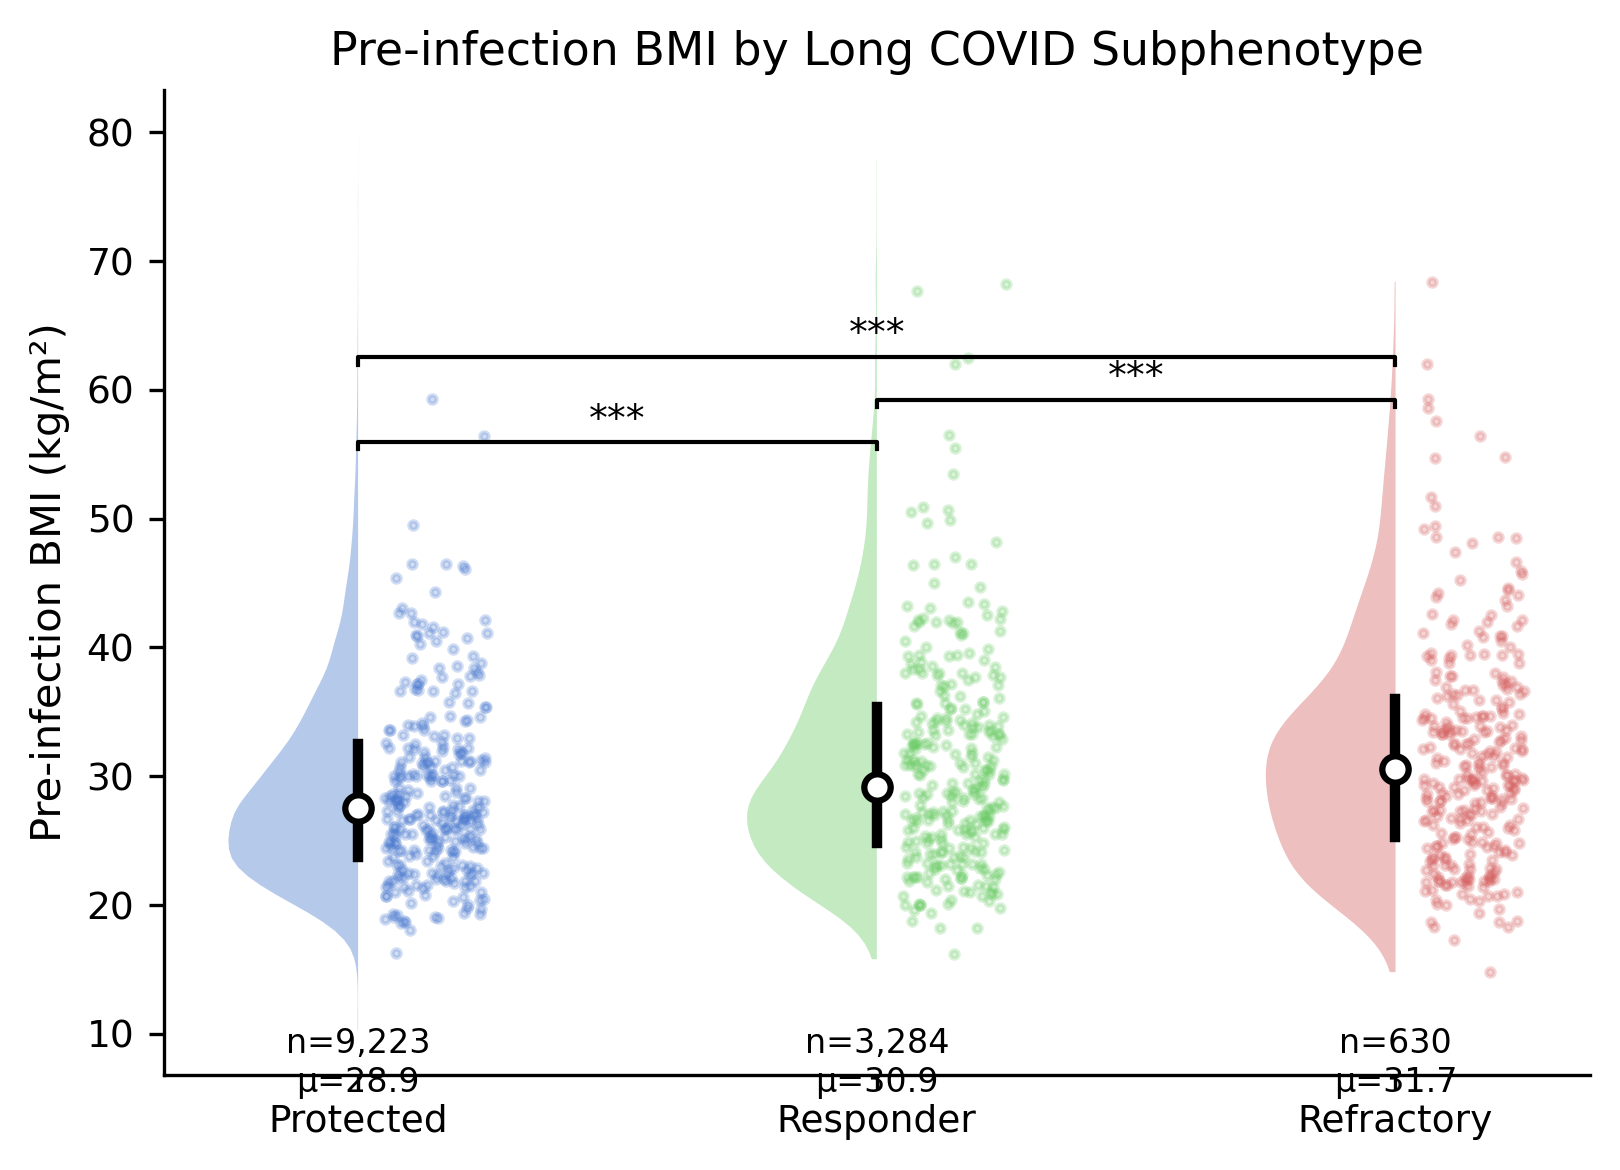

In [20]:
# ── Fig 1: Raincloud — BMI by subphenotype ────────────────────────────────
def fig_raincloud(df, outdir):
    fig, ax = plt.subplots(figsize=(5.5, 4))
    positions = np.arange(len(SUBGROUPS))
    bmi_max = df['bmi_pre'].dropna().quantile(0.99)  # robust upper limit

    for pos, grp in zip(positions, SUBGROUPS):
        data  = df.loc[df['group'] == grp, 'bmi_pre'].dropna()
        color = PALETTE[grp]

        parts = ax.violinplot(data, positions=[pos], widths=0.5,
                              showmeans=False, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color); pc.set_alpha(0.4)
            verts = pc.get_paths()[0].vertices
            m = np.mean(verts[:, 0])
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, m)  # left half only

        n_pts  = min(len(data), 300)
        sample = data.sample(n=n_pts, random_state=42)
        jitter = np.random.default_rng(42).uniform(0.05, 0.25, size=n_pts)
        ax.scatter(pos + jitter, sample, alpha=0.25, s=4, color=color, zorder=2)

        q25, q50, q75 = np.percentile(data, [25, 50, 75])
        ax.plot([pos, pos], [q25, q75], color='black', lw=2.5, zorder=3)
        ax.scatter(pos, q50, color='white', edgecolors='black', s=40, zorder=4, lw=1.5)
        ax.text(pos, 10.5, f'n={len(data):,}\nμ={data.mean():.1f}',
                ha='center', va='top', fontsize=8)

    ax.set_xticks(positions); ax.set_xticklabels(SUBGROUPS)
    ax.set_ylabel('Pre-infection BMI (kg/m²)')
    ax.set_title('Pre-infection BMI by Long COVID Subphenotype')
    add_bracket(ax, 0, 1, bmi_max * 1.02, '***')
    add_bracket(ax, 1, 2, bmi_max * 1.08, '***')
    add_bracket(ax, 0, 2, bmi_max * 1.14, '***')
    plt.tight_layout()
    for ext in ['.pdf','.png']:
        plt.savefig(outdir / f'fig1_raincloud_bmi{ext}')
    plt.show(); plt.close()

fig_raincloud(df, OUTDIR)

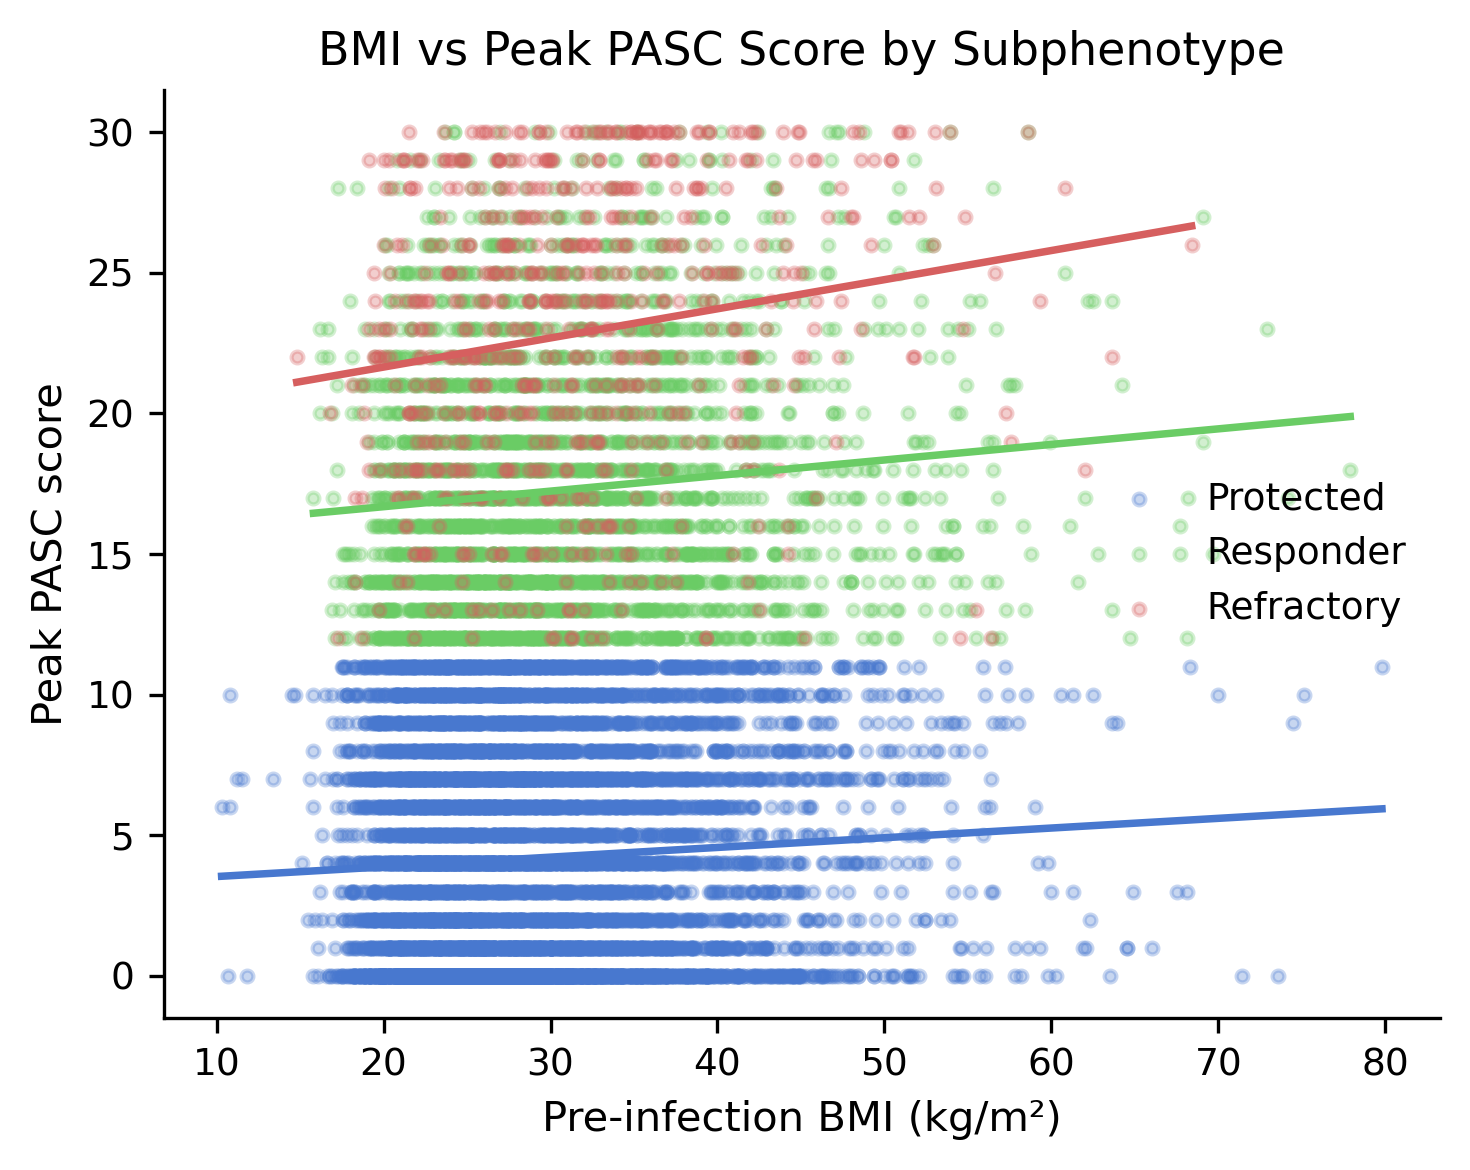

In [21]:
# ── Fig 2: Scatter — BMI vs peak PASC ────────────────────────────────────
def fig_bmi_pasc_scatter(df, outdir):
    fig, ax = plt.subplots(figsize=(5, 4))
    for grp in SUBGROUPS:
        sub = df[df['group']==grp].dropna(subset=['bmi_pre','peak_pasc'])
        ax.scatter(sub['bmi_pre'], sub['peak_pasc'],
                   alpha=0.3, s=8, label=grp, color=PALETTE[grp])
        m, b = np.polyfit(sub['bmi_pre'], sub['peak_pasc'], 1)
        xl = np.linspace(sub['bmi_pre'].min(), sub['bmi_pre'].max(), 100)
        ax.plot(xl, m*xl+b, color=PALETTE[grp], lw=1.8)
    ax.set_xlabel('Pre-infection BMI (kg/m²)')
    ax.set_ylabel('Peak PASC score')
    ax.set_title('BMI vs Peak PASC Score by Subphenotype')
    ax.legend(frameon=False)
    plt.tight_layout()
    for ext in ['.pdf','.png']:
        plt.savefig(outdir / f'fig2_bmi_pasc_scatter{ext}')
    plt.show(); plt.close()

fig_bmi_pasc_scatter(df, OUTDIR)

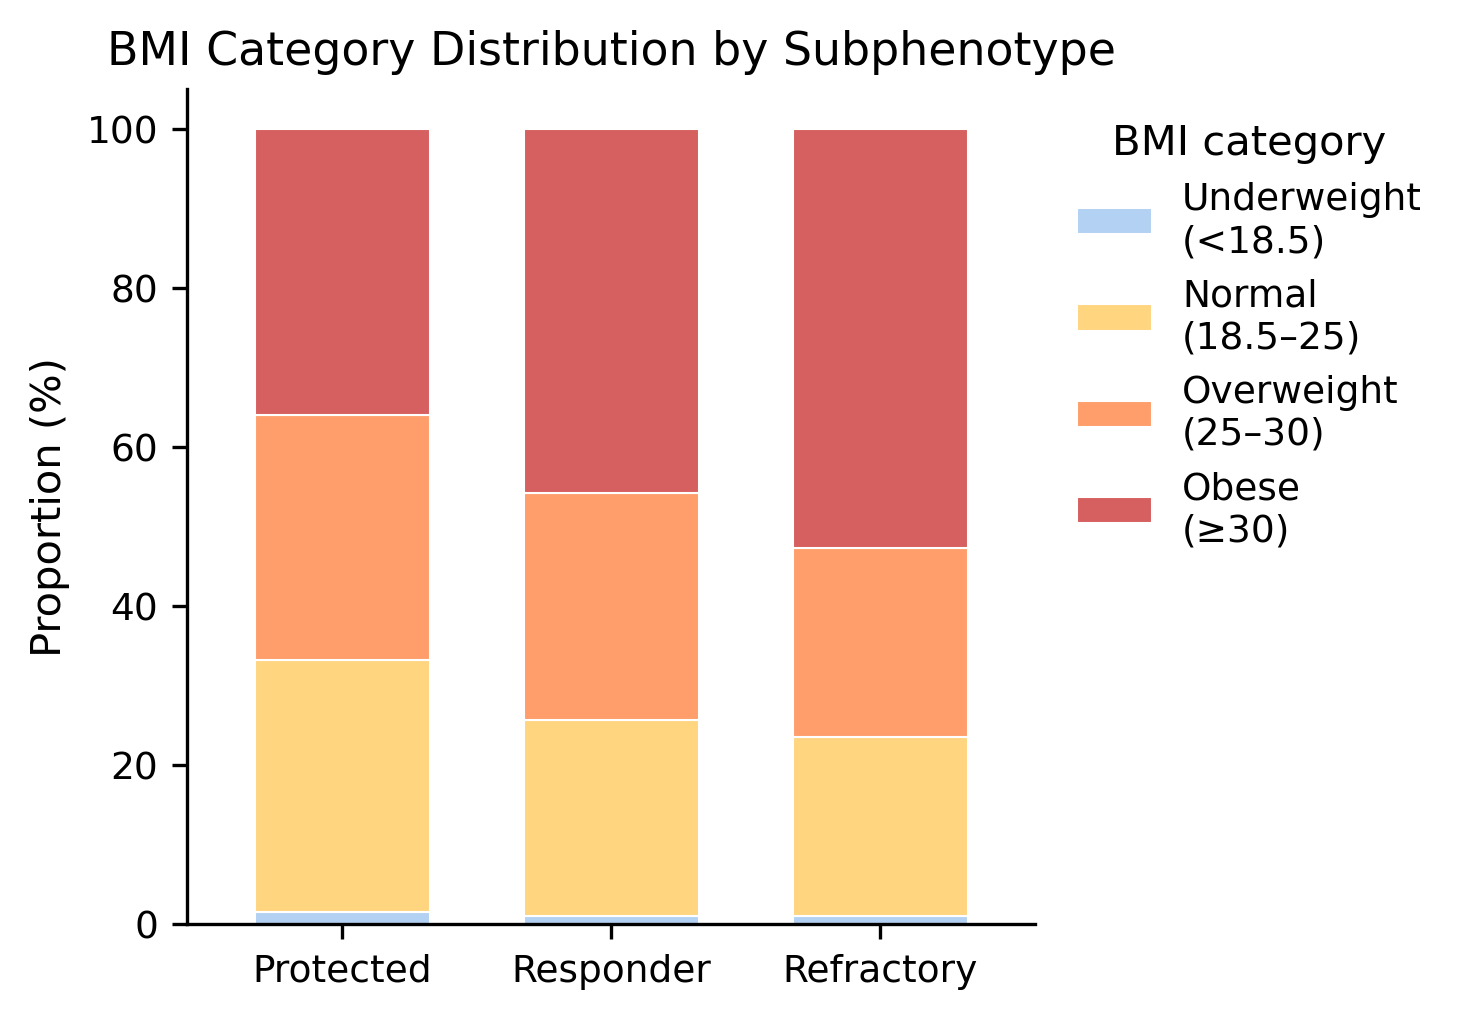

In [22]:
# ── Fig 3: Stacked bar — BMI category proportions ────────────────────────
def fig_bmi_category_stacked(df, outdir):
    ct = (df.groupby(['group','bmi_cat'], observed=True)
            .size().reset_index(name='n'))
    ct['pct'] = ct.groupby('group')['n'].transform(lambda x: x/x.sum()*100)
    pivot = (ct.pivot(index='group', columns='bmi_cat', values='pct')
               .fillna(0).loc[SUBGROUPS])

    fig, ax = plt.subplots(figsize=(5, 3.5))
    pivot.plot(kind='bar', stacked=True, ax=ax,
               color=['#B3D1F2','#FFD580','#FF9E6B','#D65F5F'],
               edgecolor='white', linewidth=0.5, width=0.65)
    ax.set_xlabel(''); ax.set_ylabel('Proportion (%)')
    ax.set_title('BMI Category Distribution by Subphenotype')
    ax.set_xticklabels(SUBGROUPS, rotation=0)
    ax.legend(title='BMI category', bbox_to_anchor=(1.01,1),
              loc='upper left', frameon=False)
    plt.tight_layout()
    for ext in ['.pdf','.png']:
        plt.savefig(outdir / f'fig3_bmi_category_stacked{ext}')
    plt.show(); plt.close()

fig_bmi_category_stacked(df, OUTDIR)

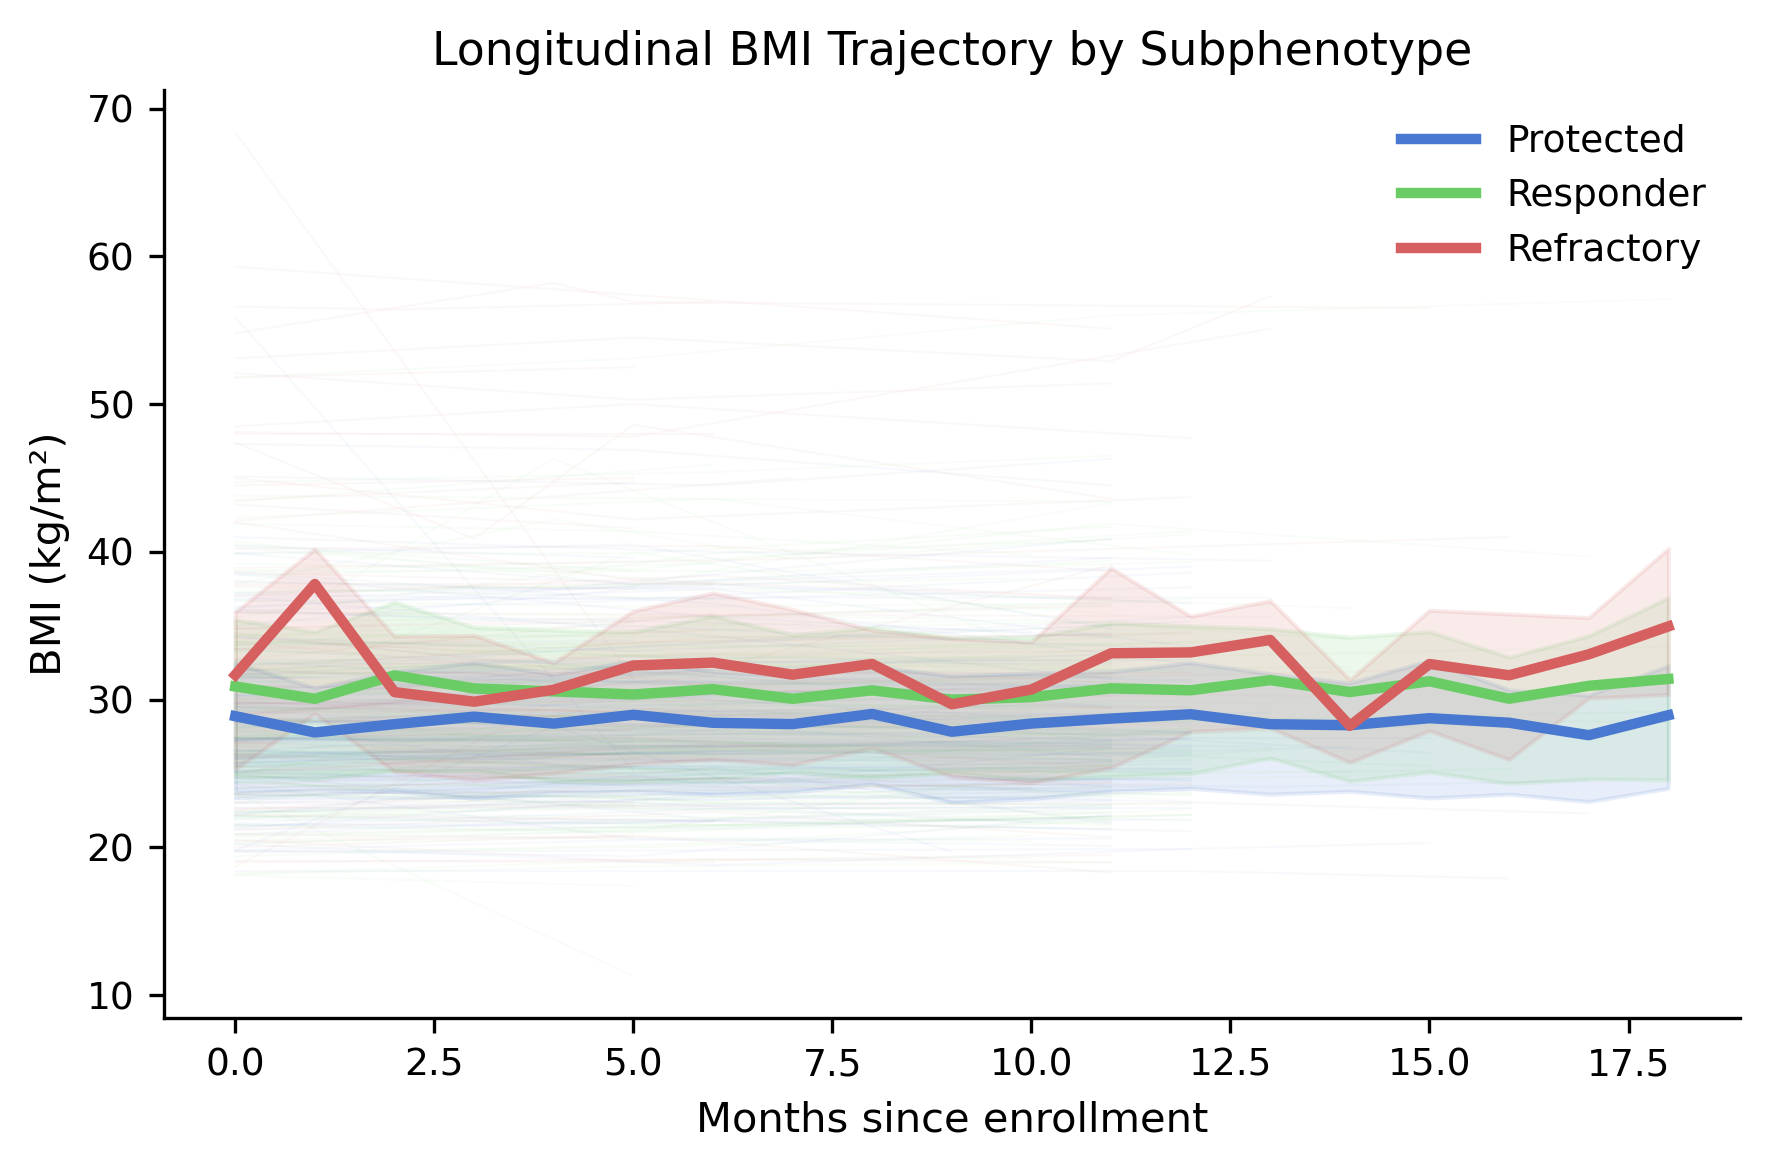

In [23]:
# ── Fig 4: Longitudinal BMI trajectory ───────────────────────────────────
def fig_bmi_trajectory(bmi_raw, subpheno, outdir):
    merged = bmi_raw.merge(subpheno, on='pid', how='inner')
    # Months since each participant's first BMI record
    merged['t0'] = merged.groupby('pid')['date'].transform('min')
    merged['month'] = ((merged['date'] - merged['t0']).dt.days / 30.44).round().astype(int)
    merged = merged[merged['month'].between(0, 18)]

    fig, ax = plt.subplots(figsize=(6, 4))
    for grp in SUBGROUPS:
        sub = merged[merged['group']==grp]
        mean_t = sub.groupby('month')['bmi'].mean()
        q25_t  = sub.groupby('month')['bmi'].quantile(0.25)
        q75_t  = sub.groupby('month')['bmi'].quantile(0.75)

        # Spaghetti (sample up to 150 pids)
        for pid in sub['pid'].unique()[:150]:
            pts = sub[sub['pid']==pid].sort_values('month')
            if len(pts) > 1:
                ax.plot(pts['month'], pts['bmi'],
                        color=PALETTE[grp], alpha=0.04, lw=0.5)
        ax.plot(mean_t.index, mean_t.values,
                color=PALETTE[grp], lw=2.5, label=grp, zorder=5)
        ax.fill_between(mean_t.index, q25_t, q75_t,
                        color=PALETTE[grp], alpha=0.12)

    ax.set_xlabel('Months since enrollment')
    ax.set_ylabel('BMI (kg/m²)')
    ax.set_title('Longitudinal BMI Trajectory by Subphenotype')
    ax.legend(frameon=False)
    plt.tight_layout()
    for ext in ['.pdf','.png']:
        plt.savefig(outdir / f'fig4_bmi_longitudinal{ext}')
    plt.show(); plt.close()

fig_bmi_trajectory(bmi_raw, subpheno, OUTDIR)

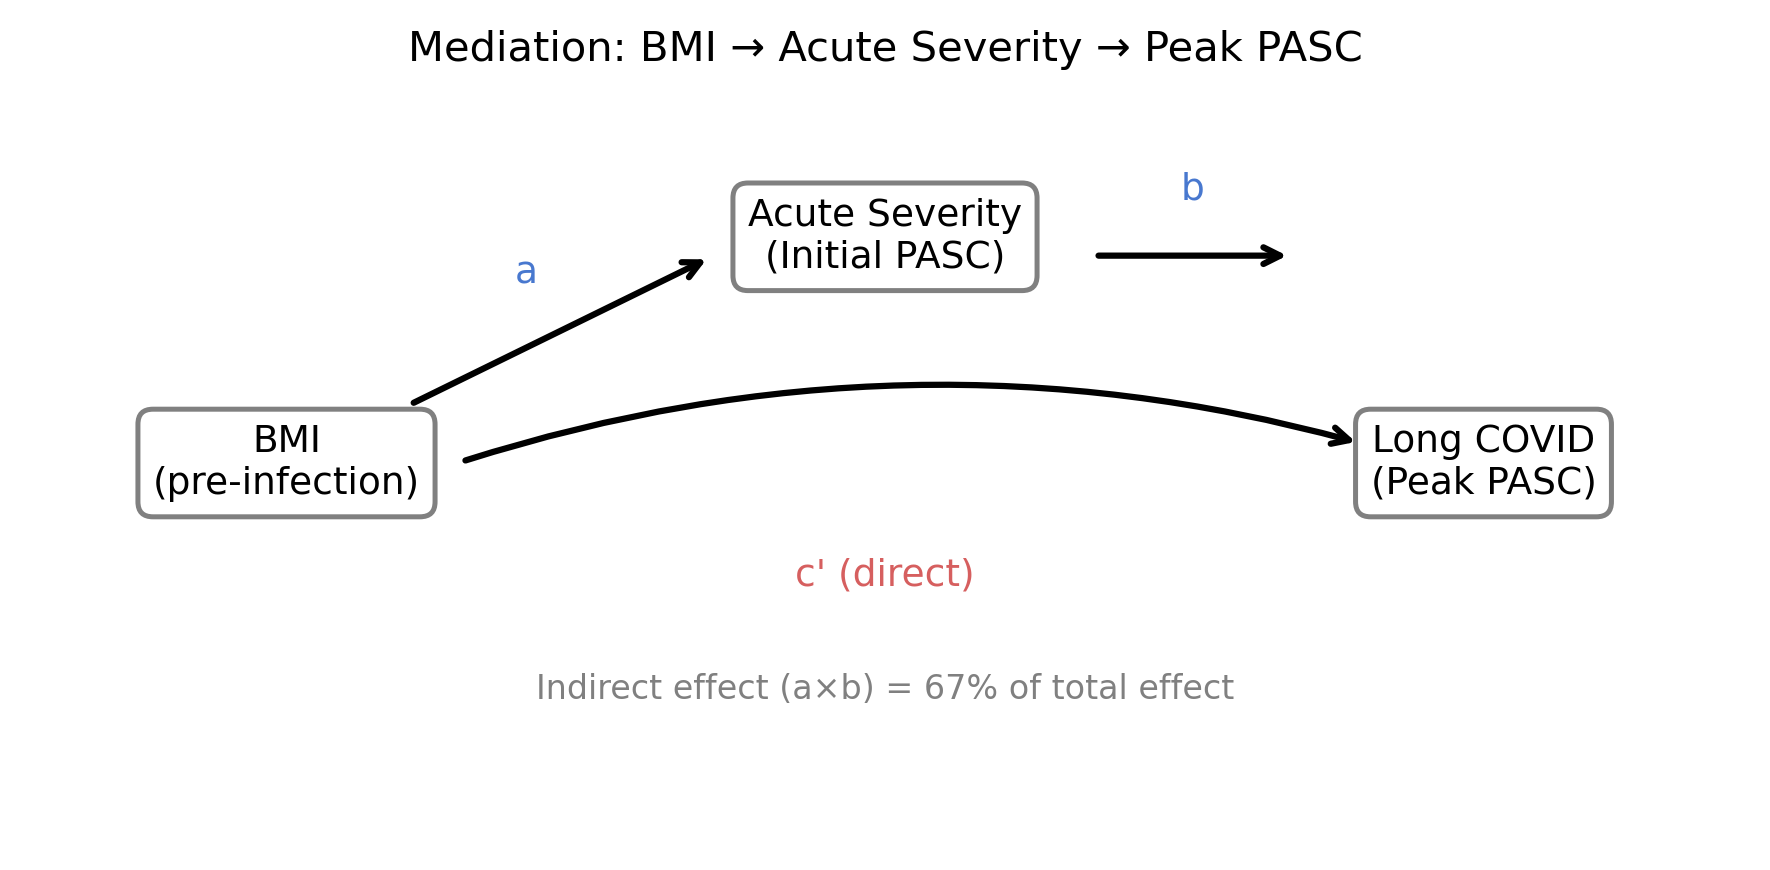

In [24]:
# ── Fig 5: Mediation path diagram ────────────────────────────────────────
def fig_mediation_diagram(outdir):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.set_xlim(0, 10); ax.set_ylim(0, 4); ax.axis('off')
    box_style = dict(boxstyle='round,pad=0.4', fc='white', ec='grey', lw=1.2)
    boxes = {'BMI\n(pre-infection)': (1.5, 2.0),
             'Acute Severity\n(Initial PASC)': (5.0, 3.2),
             'Long COVID\n(Peak PASC)': (8.5, 2.0)}
    for label, (x, y) in boxes.items():
        ax.text(x, y, label, ha='center', va='center',
                fontsize=9, bbox=box_style)
    ax.annotate('', xy=(4.0, 3.1), xytext=(2.2, 2.3),
                arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(7.4, 3.1), xytext=(6.2, 3.1),
                arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.annotate('', xy=(7.8, 2.1), xytext=(2.5, 2.0),
                arrowprops=dict(arrowstyle='->', lw=1.5,
                                connectionstyle='arc3,rad=-0.15'))
    ax.text(2.9, 2.95, 'a', fontsize=9, color='#4878CF', ha='center')
    ax.text(6.8, 3.4,  'b', fontsize=9, color='#4878CF', ha='center')
    ax.text(5.0, 1.35, "c' (direct)", fontsize=9, color='#D65F5F', ha='center')
    ax.text(5.0, 0.75,
            'Indirect effect (a×b) = 67% of total effect',
            fontsize=8, ha='center', color='grey')
    ax.set_title('Mediation: BMI → Acute Severity → Peak PASC', fontsize=10)
    plt.tight_layout()
    for ext in ['.pdf','.png']:
        plt.savefig(outdir / f'fig5_mediation_diagram{ext}')
    plt.show(); plt.close()

fig_mediation_diagram(OUTDIR)

In [ ]:
# ── Fig 6: Heatmap — Pearson r by subphenotype ───────────────────────────
def fig_heatmap_correlations(df, outdir):
    feats  = ['bmi_pre','initial_pasc','peak_pasc']
    labels = ['All'] + SUBGROUPS
    records = []
    for grp in labels:
        sub = df if grp == 'All' else df[df['group']==grp]
        sub = sub[feats].dropna()
        r1, _ = stats.pearsonr(sub['bmi_pre'], sub['initial_pasc'])
        r2, _ = stats.pearsonr(sub['bmi_pre'], sub['peak_pasc'])
        records.append({'Group': grp, 'BMI vs Initial PASC': r1,
                                       'BMI vs Peak PASC':    r2})
    r_df = pd.DataFrame(records).set_index('Group')

    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(r_df, annot=True, fmt='.3f', cmap='coolwarm',
                center=0, vmin=-0.6, vmax=0.6,
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Pearson r'})
    ax.set_title('Pearson r: BMI vs PASC scores by subphenotype')
    plt.tight_layout()
    for ext in ['.pdf','.png']:
        plt.savefig(outdir / f'fig6_heatmap_correlations{ext}')
    plt.show(); plt.close()

fig_heatmap_correlations(df, OUTDIR)

In [ ]:
print('\n✓ All outputs saved to:', OUTDIR.resolve())
for f in sorted(OUTDIR.iterdir()):
    print(' ', f.name)